In [12]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

connection = sqlite3.connect("bank_data.db")

query = "SELECT * FROM applicants;"
df = pd.read_sql_query(query, connection)

connection.close()


In [13]:
!pip install seaborn matplotlib


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
print("--- Missing Values Per Column ---")
print(df.isnull().sum())


print("\n--- Distribution of the Target Variable (Default) ---")
print(df['credit_risk'].value_counts())

--- Missing Values Per Column ---
status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

--- Distribution of the Target Variable (Default) ---
credit_risk
1    700
0    300
Name: count, dtype: int64


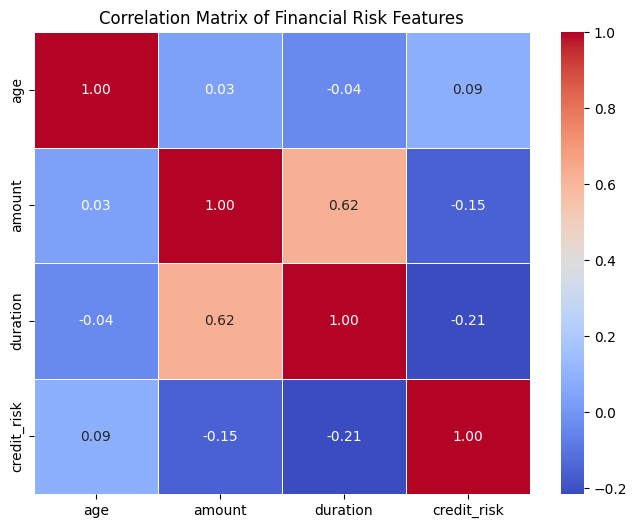

In [16]:

numerical_cols = ['age', 'amount', 'duration', 'credit_risk']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Financial Risk Features")
plt.show()

In [17]:

categorical_cols = ['status', 'credit_history', 'purpose', 'savings', 
                    'employment_duration', 'personal_status_sex', 
                    'other_debtors', 'property', 'other_installment_plans', 
                    'housing', 'job', 'telephone', 'foreign_worker']


df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


print(f"Original shape: {df.shape}")
print(f"New encoded shape: {df_encoded.shape}")

Original shape: (1000, 21)
New encoded shape: (1000, 49)
